In [14]:
import pandas as pd
import numpy as np
import pickle

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, ParameterGrid
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, r2_score

import shap
import warnings
warnings.filterwarnings('ignore')


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("startup_success_dataset.csv") 

# Preview
print(df.head())
print(df.info())

   funding_rounds  founder_experience_years  team_size  market_size_billion  \
0               4                        13         58            48.225483   
1               1                         6        221            31.532647   
2               3                         5        247             4.969722   
3               3                        14        229             3.084209   
4               1                        17        235            13.818188   

   product_traction_users  burn_rate_million  revenue_million investor_type  \
0                  594843          18.519211     1.483962e+06      tier2_vc   
1                  393020          14.298149     8.620568e+05      tier2_vc   
2                   27636          20.447567     9.726169e+04          none   
3                  235376           8.177417     1.145785e+06          none   
4                  391765           4.879792     8.608949e+05          none   

      sector founder_background      outcome  
0  

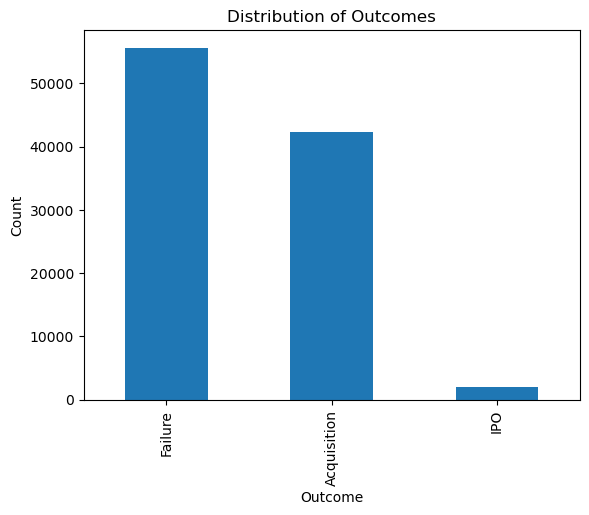

In [16]:
plt.figure()
df['outcome'].value_counts().plot(kind='bar')
plt.title("Distribution of Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

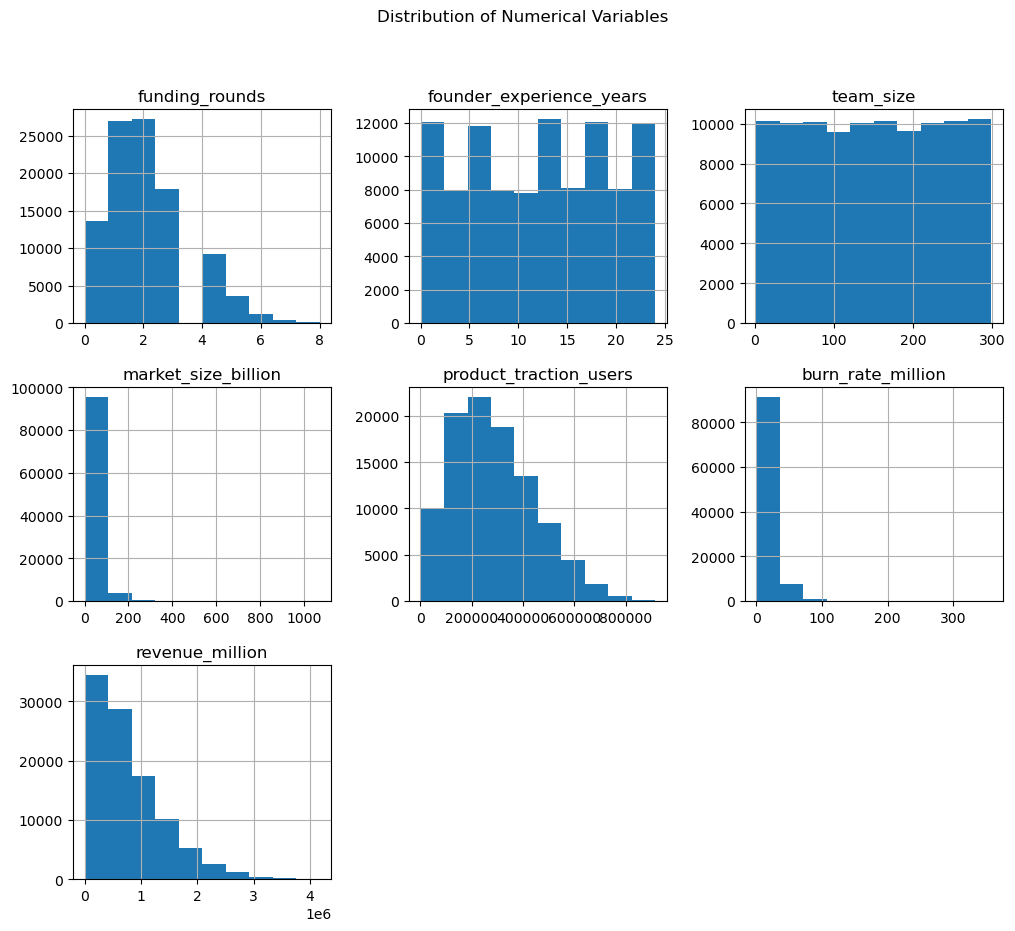

In [17]:
df.hist(figsize=(12,10))
plt.suptitle("Distribution of Numerical Variables")
plt.show()

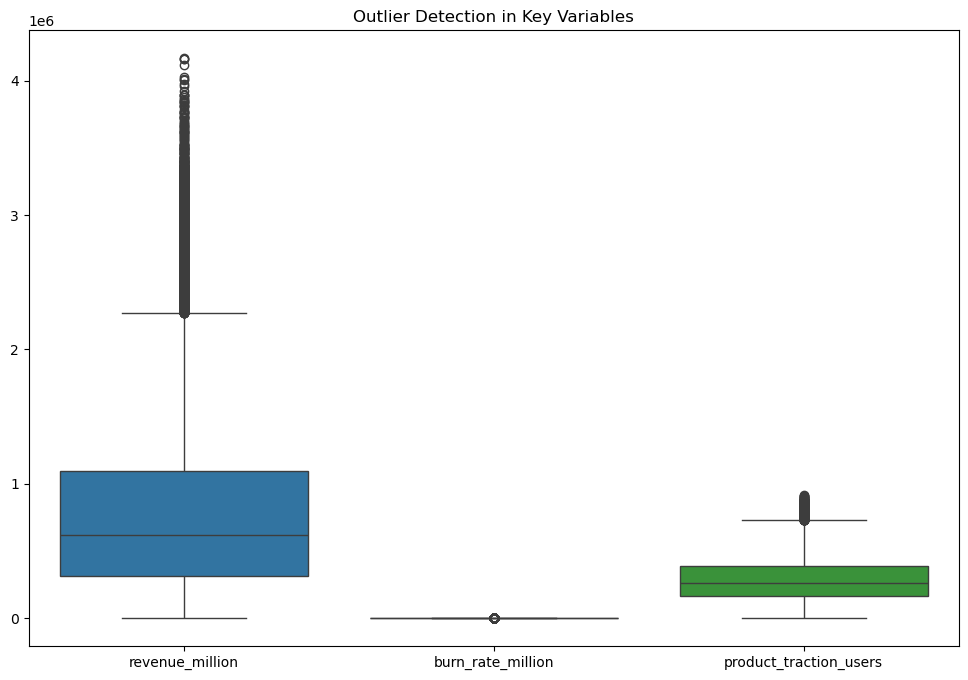

In [18]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.boxplot(data=df[['revenue_million','burn_rate_million','product_traction_users']])
plt.title("Outlier Detection in Key Variables")
plt.show()

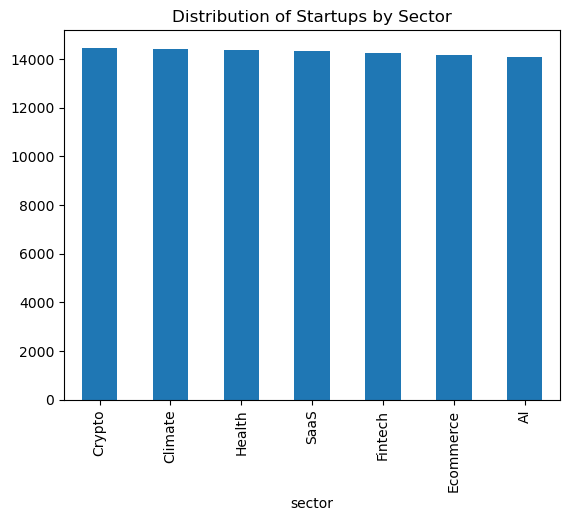

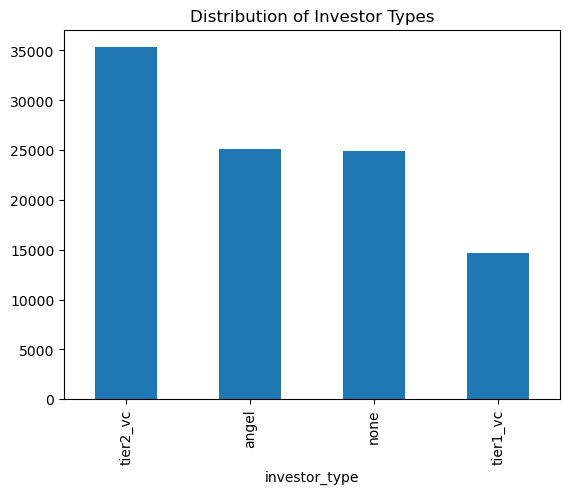

In [19]:
plt.figure()
df['sector'].value_counts().plot(kind='bar')
plt.title("Distribution of Startups by Sector")
plt.show()

plt.figure()
df['investor_type'].value_counts().plot(kind='bar')
plt.title("Distribution of Investor Types")
plt.show()

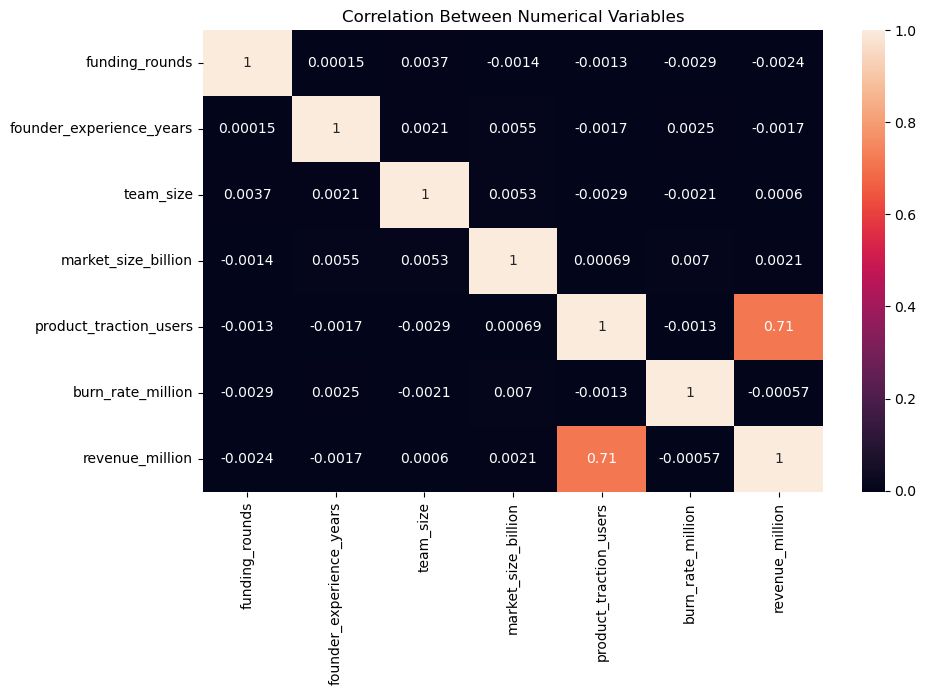

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Between Numerical Variables")
plt.show()

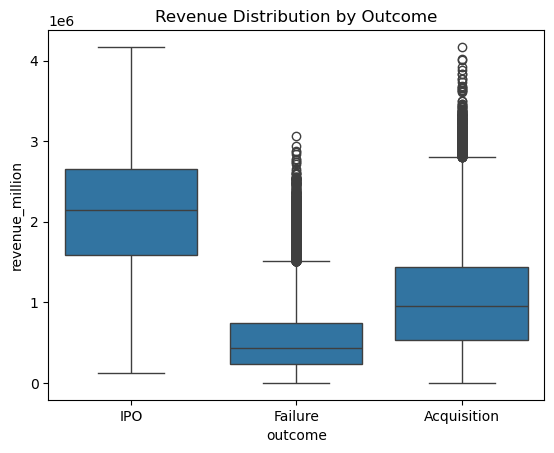

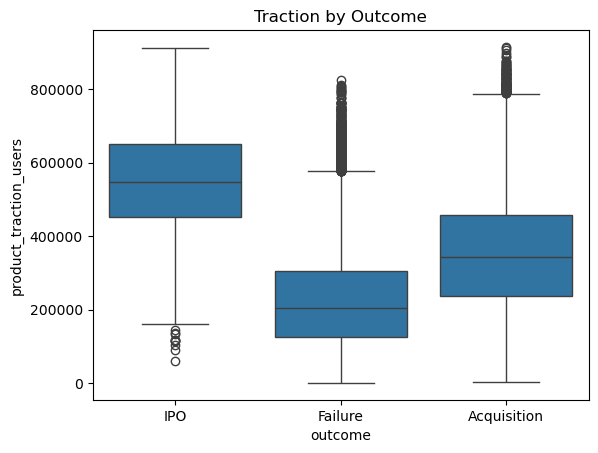

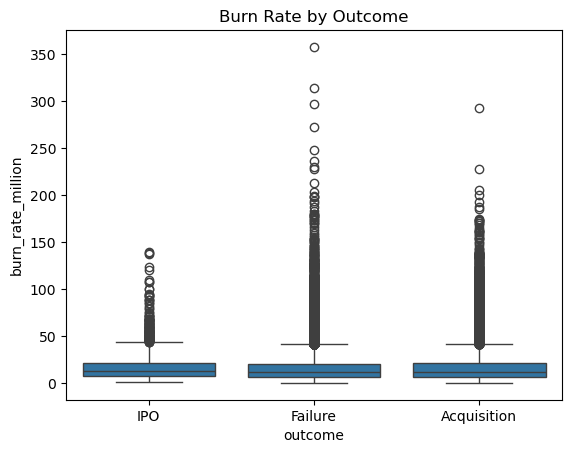

In [21]:
sns.boxplot(x='outcome', y='revenue_million', data=df)
plt.title("Revenue Distribution by Outcome")
plt.show()

sns.boxplot(x='outcome', y='product_traction_users', data=df)
plt.title("Traction by Outcome")
plt.show()

sns.boxplot(x='outcome', y='burn_rate_million', data=df)
plt.title("Burn Rate by Outcome")
plt.show()

In [22]:
# 3. Target Creation (Binary Success)
df['success'] = df['outcome'].apply(lambda x: 1 if x in ['IPO','Acquisition'] else 0)
print(df['success'].value_counts())

success
0    55610
1    44390
Name: count, dtype: int64


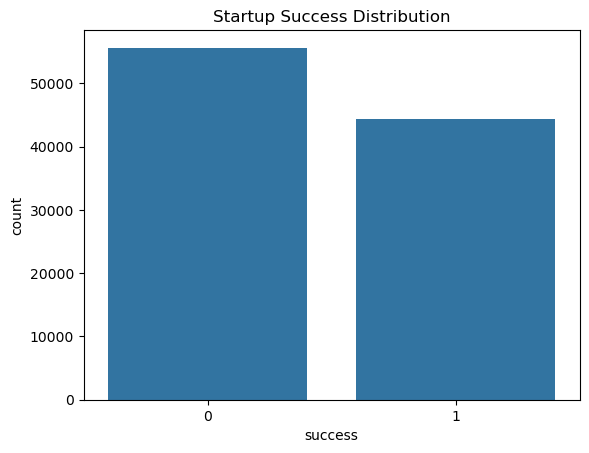

Success Ratio: 0.4439


In [23]:
sns.countplot(x='success', data=df)
plt.title("Startup Success Distribution")
plt.show()

print("Success Ratio:", df['success'].mean())

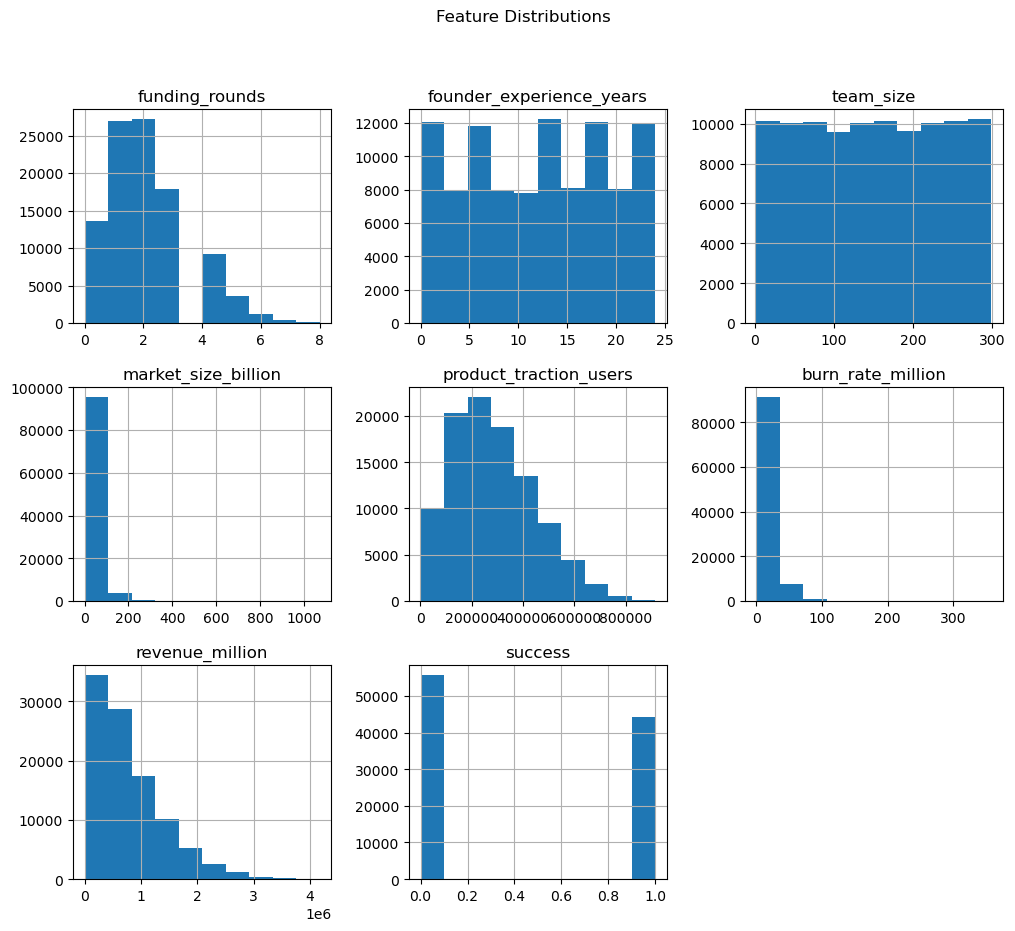

In [24]:
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

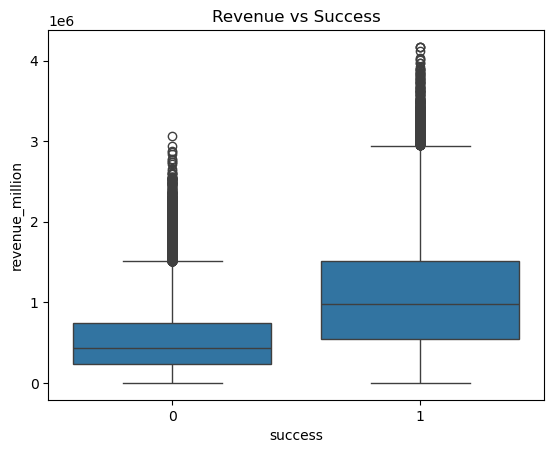

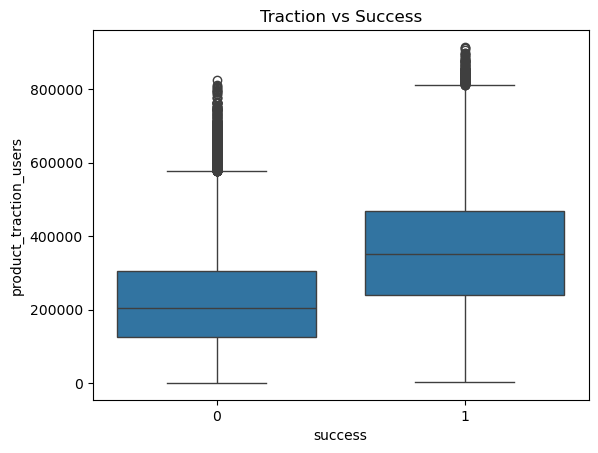

In [25]:
sns.boxplot(x='success', y='revenue_million', data=df)
plt.title("Revenue vs Success")
plt.show()

sns.boxplot(x='success', y='product_traction_users', data=df)
plt.title("Traction vs Success")
plt.show()

In [26]:
cat_cols = ['investor_type','sector','founder_background']

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

X = df.drop(columns=['outcome','success'])
y = df['success']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (80000, 10)
Test Shape: (20000, 10)


In [45]:
def evaluate(model, X, y):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        
        score = f1_score(y_val, preds)
        scores.append(score)
    
    mean_score = np.mean(scores)
    print("Fold Scores:", scores)
    print("Mean CV Score:", mean_score)
    
    return mean_score

In [46]:
models = {
    "Logistic": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "CatBoost": CatBoostClassifier(verbose=0)
}

results = {}

for name, model in models.items():
    print("\nEvaluating:", name)
    
    if name == "Logistic":
        score = evaluate(model, X_train_scaled, y_train)
    else:
        score = evaluate(model, X_train.values, y_train)
    
    results[name] = score
    print("F1 Score:", score)

best_model_name = max(results, key=results.get)
print("\nBest Model:", best_model_name)


Evaluating: Logistic
Fold Scores: [0.7321729365524986, 0.7302052785923754, 0.7269429328868424, 0.7304299506841703, 0.7272600446428571]
Mean CV Score: 0.7294022286717488
F1 Score: 0.7294022286717488

Evaluating: Random Forest
Fold Scores: [0.7110582639714625, 0.7099528857479388, 0.7051766274161297, 0.7095262502745845, 0.7049434715140767]
Mean CV Score: 0.7081314997848385
F1 Score: 0.7081314997848385

Evaluating: XGBoost
Fold Scores: [0.7136537894426422, 0.7144108628996934, 0.7050518420472094, 0.7066287464449792, 0.7046989720998531]
Mean CV Score: 0.7088888425868756
F1 Score: 0.7088888425868756

Evaluating: CatBoost
Fold Scores: [0.7166036897088242, 0.7196480938416422, 0.7139591475554901, 0.7109546854377474, 0.7100626612605971]
Mean CV Score: 0.7142456555608602
F1 Score: 0.7142456555608602

Best Model: Logistic


In [47]:
param_grid = {
    "Random Forest": {'n_estimators':[100,200], 'max_depth':[None,10]},
    "XGBoost": {'n_estimators':[100,200], 'max_depth':[3,6]},
    "CatBoost": {'iterations':[100,200], 'depth':[4,6]}
}

best_model = models[best_model_name]

if best_model_name in param_grid:
    best_score = 0
    best_params = None
    
    for params in ParameterGrid(param_grid[best_model_name]):
        model = best_model.set_params(**params)
        
        score = evaluate(model, X_train.values, y_train)
        print("Score:", score)
        
        if score > best_score:
            best_score = score
            best_params = params
    
    print("Best Params:", best_params)
    print("Best Score:", best_score)

In [48]:
if best_model_name == "Logistic":
    best_model.fit(X_train_scaled, y_train)
    preds = best_model.predict(X_test_scaled)
else:
    best_model.fit(X_train, y_train)
    preds = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print("F1 Score:", f1_score(y_test, preds))

print("\nClassification Report:\n")
print(classification_report(y_test, preds))

Accuracy: 0.7644
F1 Score: 0.7356076759061834

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.79      0.79     11122
           1       0.73      0.74      0.74      8878

    accuracy                           0.76     20000
   macro avg       0.76      0.76      0.76     20000
weighted avg       0.76      0.76      0.76     20000



In [44]:
print("Best Model:", best_model_name)

if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=X.columns)
    
    importance.sort_values(ascending=False).head(10).plot(kind='bar')
    plt.title("Top Features")
    plt.show()
else:
    print("⚠️ Feature importance not available for this model")

Best Model: Logistic
⚠️ Feature importance not available for this model
